<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_on_Real_Estate_(Notebook_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")


All libraries installed.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [ ]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                     ║
# ╚════════════════════════════════════════════════════╝

import os
import re
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import math
import matplotlib.patches as mpatches

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score, precision_score, recall_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.ensemble import HistGradientBoostingRegressor

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)


All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


# Notebook 2 — Restore Checkpoint from Notebook 1

After completion of notebook 1 we load the complete Python session in the final
cell and restore it for notebook 2 all the dataframes, constants, and NLP profiles are available now and we can now continue the same session in notebook 2.

**Variables restored include:**
`df_combined`, `df_txny`, `nlp_profile`, `NLP_COLS`, `BED_COL`, `BATH_COL`,
`SQFT_COL`, `CITY_COL`, `SAVE_DIR`, `SEED`, and all feature engineering outputs.




In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 2: SETUP — restores state from Notebook 1              ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Loads all the variables that were saved by Notebook 1's checkpoint cell.

Restore process:
    1. Load main checkpoint .pkl → globals().update(_state)
       This makes all the variables from Notebook 1 available in this session.
    2. Load_keras.json → for each entry, keras.models.load_model(path)
       Restores any Keras models that were saved during Notebook 1.

Verification:
    Prints the number of variables that were restored and the Keras models loaded.
    Confirms df_combined are available and reports its shape.

Prerequisites:
    - Google Drive must be mounted (Cell 2)
    - SAVE_DIR must match the path used in Notebook 1
    - checkpoint_1_to_2.pkl must exist in SAVE_DIR/checkpoints/

Common issues:
    PermissionError : Notebook 1 Drive session is still open.
                      Close Notebook 1 tab and retry.
    FileNotFoundError : Notebook 1 checkpoint was not saved.
                        Re-run Notebook 1 completely.
    KeyError on df_combined : Checkpoint is from the different version.
                              So we need to delete old checkpoint and re-run Notebook 1.
"""

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, json

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
CKPT_NAME = "checkpoint_1_to_2"

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "rb") as f:
    _state = dill.load(f)
globals().update(_state)

with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json") as f:
    _keras_paths = json.load(f)
for _name, _path in _keras_paths.items():
    globals()[_name] = keras.models.load_model(_path)

print("=" * 65)
print(f"CHECKPOINT RESTORED <- {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables restored    : {len(_state)}")
print(f"  Keras models restored : {list(_keras_paths.keys()) or 'none'}")
if "df_combined" in globals():
    print(f"  df_combined shape      : {df_combined.shape}")
print(f"\nNotebook 1 state loaded.")



CHECKPOINT RESTORED <- /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_1_to_2.pkl
  Variables restored    : 193
  Keras models restored : none
  df_combined shape      : (149999, 49)

Notebook 1 state loaded.


#Cell 17: Feature Matrix + 80/10/10 Split

The final feature matrix is built from `df_combined` and split it into train,
validation, test sets and also confirms zero data leakage.

## Split Design:

| Set | Size | Purpose |
|---|---|---|
| Train (80%) | ~119K rows | Fit all models and meta-learner |
| Validation (10%) | ~15K rows | Tune Optuna hyperparameters |
| Test (10%) | ~15K rows | Final held-out evaluation |

## Leakage Prevention:

From training rows zip_median_price and city_median_price are computed using
`add_leak_free_encoding()`. The encoding values for Validation and Test rows
are received from the training map and not their own prices. Because of this the model sees test-set price information during the training.

## MLP Target Normalisation:

`log_price` is standardised to zero mean and unit variance for MLP training:
```python
yr_tr_sc = (y_reg_train - mean) / std
```
Tree models does not require this; MLP benefits significantly from normalised targets.






In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — FEATURE MATRIX + LEAK-FREE 80/10/10 SPLIT             ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Builds the final feature matrix and splits into train/val/test.

Final feature list (28 features):
  Structural (6)  : bed, bath, house_size, acre_lot, log_house_size, bed_bath_ratio
  Location  (3)   : is_tx_listing, is_ny_listing, zip_numeric,
  NLP       (14)  : nlp_vader_compound_mean/std, nlp_vader_pos_mean/std,
                    nlp_vader_neg_mean/std, nlp_flesch_ease_mean/std,
                    nlp_flesch_kincaid_mean/std, nlp_luxury_score_mean/std,
                    nlp_description_word_count_mean/std
  Derived   (3)   : price_per_sqft, latitude, longitude
  Encodings (2)   : zip_median_price, city_median_price

Task A target (regression):
    y_reg = df_combined["log_price"]

Task B target (classification):
    y_clf = df_combined["status_binary"]  (1=sold, 0=for_sale, NaN=other)
    Filtered to rows where status ∈ {"for_sale", "sold"} only.
    Coverage check: if < 5% of rows have valid status, Task B is skipped.

80/10/10 split:
    Stage 1: train_test_split(test_size=0.10)         → 90% train+val, 10% test
    Stage 2: train_test_split(test_size=0.10/0.90)    → 80% train, 10% val

Leak-free target encoding:
    Function: add_leak_free_encoding(X, z_series, c_series)
    zip_med_tr  = training rows only → median(price) grouped by zip_numeric
    city_med_tr = training rows only → median(price) grouped by city
    Val/test rows are mapped using training medians; unseen zip/city → global median.

Arrays prepared:
    Xtr_raw, Xva_raw, Xts_raw : raw numpy arrays for tree/linear models
    Xtr_sc, Xva_sc, Xts_sc    : imputed + StandardScaler arrays for MLP
    yr_tr_sc, yr_va_sc        : normalised log_price for MLP training

Helper functions defined:
    norm_y(y)   : standardise log_price to zero mean, unit variance
    denorm_y(y) : inverse of norm_y — converts MLP predictions back to log_price scale
"""

print("=" * 65)
print("CELL 17 — FEATURE MATRIX + TRAIN/VAL/TEST SPLIT")
print("=" * 65)

# Feature list
structural_feat = [c for c in [bed_col, bath_col, sqft_col, "acre_lot",
                                "log_house_size", "bed_bath_ratio"]
                   if c and c in df_combined.columns]
location_feat   = [c for c in ["is_tx_listing", "is_ny_listing",
                                "zip_numeric", "latitude", "longitude"]
                   if c in df_combined.columns]
derived_feat    = [c for c in ["price_per_sqft"] if c in df_combined.columns]
nlp_feat        = [c for c in df_combined.columns if c.startswith("nlp_")]

# Placeholder columns for leak-free encodings
encoding_feat   = ["zip_median_price", "city_median_price"]

base_features   = structural_feat + location_feat + derived_feat + nlp_feat
all_features    = base_features + encoding_feat
all_features    = list(dict.fromkeys(all_features))  # deduplicate

print(f"\nFeature groups:")
print(f"  Structural ({len(structural_feat)}) : {structural_feat}")
print(f"  Location   ({len(location_feat)})  : {location_feat}")
print(f"  Derived    ({len(derived_feat)})   : {derived_feat}")
print(f"  NLP        ({len(nlp_feat)})       : {nlp_feat[:4]} ...")
print(f"  Encodings  ({len(encoding_feat)})  : {encoding_feat}")
print(f"  TOTAL features: {len(all_features)}")

# Task A — regression
y_reg = df_combined["log_price"].copy()

# Task B classification — normalise status and filter to for_sale / sold
y_clf = None
if "status" in df_combined.columns:
    status_norm = df_combined["status"].astype(str).str.lower().str.strip()
    valid_mask  = status_norm.isin(["for_sale", "sold"])
    df_combined["status_binary"] = np.nan
    df_combined.loc[valid_mask, "status_binary"] = (
        status_norm[valid_mask] == "sold").astype(int)
    clf_coverage = valid_mask.mean()
    print(f"\nTask B status coverage (for_sale/sold): {clf_coverage:.1%}")
    if clf_coverage >= 0.05:
        y_clf = df_combined["status_binary"]
        print(f"  sold=1: {(y_clf==1).sum():,}  for_sale=0: {(y_clf==0).sum():,}")
    else:
        print("  Coverage <5% — Task B skipped")

# Price band for stratification
df_combined["price_band"] = pd.qcut(
    df_combined["price"], q=4, labels=["Q1","Q2","Q3","Q4"])

X_all    = df_combined[base_features].copy()
price_s  = df_combined["price"].copy()
city_s   = df_combined[city_col].copy() if city_col else pd.Series(["UNK"]*len(df_combined))
zip_s    = df_combined["zip_numeric"].copy() if "zip_numeric" in df_combined.columns \
           else pd.Series([np.nan]*len(df_combined))
pband_s  = df_combined["price_band"].astype(str)

X_trval, X_test, y_reg_trval, y_reg_test, \
p_trval, p_test, c_trval, c_test, \
z_trval, z_test, pb_trval, pb_test = train_test_split(
    X_all, y_reg, price_s, city_s, zip_s, pband_s,
    test_size=0.10, random_state=SEED, stratify=pband_s)

X_train, X_val, y_reg_train, y_reg_val, \
p_train, p_val, c_train, c_val, \
z_train, z_val = train_test_split(
    X_trval, y_reg_trval, p_trval, c_trval, z_trval,
    test_size=0.10/0.90, random_state=SEED, stratify=pb_trval)

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train):,} rows ({len(X_train)/len(df_combined)*100:.0f}%)")
print(f"  Val   : {len(X_val):,} rows ({len(X_val)/len(df_combined)*100:.0f}%)")
print(f"  Test  : {len(X_test):,} rows ({len(X_test)/len(df_combined)*100:.0f}%)")

# Leak-free target encoding
print("\nComputing leak-free target encodings from training rows only")
g_global = float(p_train.median())

# zip_median_price
if "zip_numeric" in X_train.columns:
    zip_med_tr  = pd.concat([z_train, p_train], axis=1).groupby("zip_numeric")["price"].median()
    g_zip       = float(zip_med_tr.median())
else:
    zip_med_tr  = pd.Series(dtype=float)
    g_zip       = g_global

# city_median_price
cc = city_col if city_col else "city"
city_med_tr = pd.concat([c_train, p_train], axis=1).groupby(cc)["price"].median()
g_city      = float(city_med_tr.median())

def add_leak_free_encoding(X, z_series, c_series):
    """Add zip and city median price encodings using ONLY training medians."""
    X = X.copy()
    if "zip_numeric" in X.columns:
        X["zip_median_price"]  = z_series.map(zip_med_tr).fillna(g_zip)
    else:
        X["zip_median_price"]  = g_zip
    X["city_median_price"] = c_series.map(city_med_tr).fillna(g_city)
    return X

X_train = add_leak_free_encoding(X_train, z_train, c_train)
X_val   = add_leak_free_encoding(X_val,   z_val,   c_val)
X_test  = add_leak_free_encoding(X_test,  z_test,  c_test)

# Update final feature list
final_features = [c for c in all_features if c in X_train.columns]
final_features = list(dict.fromkeys(final_features))

print(f"Final feature count after encodings: {len(final_features)}")
print(f"Top correlations with log_price (train):")
tr_corr = X_train[final_features].corrwith(y_reg_train).abs().sort_values(ascending=False)
print(tr_corr.head(10).round(4).to_string())

# Classification split (Task B)
y_clf_train = y_clf_val = y_clf_test = None
if y_clf is not None:
    y_clf_train = y_clf.loc[X_train.index]
    y_clf_val   = y_clf.loc[X_val.index]
    y_clf_test  = y_clf.loc[X_test.index]
    clf_mask_tr  = y_clf_train.notna()
    clf_mask_val = y_clf_val.notna()
    clf_mask_tst = y_clf_test.notna()

# Raw numpy arrays for tree/linear models
Xtr_raw  = X_train[final_features].values
Xva_raw  = X_val[final_features].values
Xts_raw  = X_test[final_features].values

# Scaled arrays for MLP
mlp_pipe = SKPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
Xtr_sc   = mlp_pipe.fit_transform(Xtr_raw)
Xva_sc   = mlp_pipe.transform(Xva_raw)
Xts_sc   = mlp_pipe.transform(Xts_raw)
n_feat   = Xtr_sc.shape[1]

# MLP target normalisation
yr_tr_mean = float(y_reg_train.mean())
yr_tr_std  = float(y_reg_train.std())
def norm_y(y):   return (np.array(y) - yr_tr_mean) / yr_tr_std
def denorm_y(y): return np.array(y) * yr_tr_std + yr_tr_mean

yr_tr_sc = norm_y(y_reg_train.values)
yr_va_sc = norm_y(y_reg_val.values)

print("\nFeature matrix ready:")
print(f"  Tree/linear (raw)  : {Xtr_raw.shape}")
print(f"  MLP               : {Xtr_sc.shape}")
print(f"  NaN in Xtr_raw     : {np.isnan(Xtr_raw).sum():,}  "
      f"(zip_numeric 30% NaN — HGB handles natively)")
print(f"  NaN in Xtr_sc      : {np.isnan(Xtr_sc).sum()} ")

CELL 17 — FEATURE MATRIX + TRAIN/VAL/TEST SPLIT

Feature groups:
  Structural (6) : ['bed', 'bath', 'house_size', 'acre_lot', 'log_house_size', 'bed_bath_ratio']
  Location   (5)  : ['is_tx_listing', 'is_ny_listing', 'zip_numeric', 'latitude', 'longitude']
  Derived    (1)   : ['price_per_sqft']
  NLP        (14)       : ['nlp_vader_compound_mean', 'nlp_vader_compound_std', 'nlp_vader_pos_mean', 'nlp_vader_pos_std'] ...
  Encodings  (2)  : ['zip_median_price', 'city_median_price']
  TOTAL features: 28

Task B status coverage (for_sale/sold): 67.9%
  sold=1: 30,141  for_sale=0: 71,776

Split sizes:
  Train : 119,999 rows (80%)
  Val   : 15,000 rows (10%)
  Test  : 15,000 rows (10%)

Computing leak-free target encodings from training rows only
Final feature count after encodings: 28
Top correlations with log_price (train):
city_median_price   0.5201
zip_median_price    0.4497
price_per_sqft      0.4442
bath                0.3143
bed                 0.1980
bed_bath_ratio      0.1282
log_h

# Cell 18: Evaluation Helper

Defines `evaluate_reg()` — a shared function which will be used by all the model evaluation cells throughout Notebooks 2, 3, and 4.

Returns a dictionary of 4 metrics:

| Metric | Formula | Unit |
|---|---|---|
| R² | Coefficient of determination | 0–1 (higher = better) |
| RMSE | Root mean squared error | log(price) units |
| MAE | Mean absolute error | log(price) units |
| Real-$ MAE | `mean_absolute_error(expm1(y_true), expm1(y_pred))` | US dollars |

The most interpretable metric is **Real-$ MAE** for the business audience
because it tells the agent about how many dollars the model's price is off
from its average.




In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 18 — EVALUATION HELPER                                     ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Defines the shared evaluation function that is used throughout
the modelling pipeline.

Function defined:
    evaluate_reg(y_true, y_pred, label="", split="val") -> dict
        Computes regression metrics and prints a formatted summary line.

        Args:
            y_true (array-like) : actual log_price values
            y_pred (array-like) : predicted log_price values
            label  (str)        : model name for printing the output
            split  (str)        : "val" or "test" — shown in output

        Returns:
            dict with keys: model, split, R2, RMSE, MAE, Real_MAE_USD

        Metrics computed:
            RMSE        : sqrt(mean_squared_error(y_true, y_pred))
            MAE         : mean_absolute_error(y_true, y_pred)
            R2          : r2_score(y_true, y_pred)
            Real_MAE_USD: mean_absolute_error(expm1(y_true), expm1(y_pred))
                          Back-transforms from log scale to dollars.
                          Directly interpretable for real estate agents.

Lists initialised:
    results_baseline (list) : appended to by Cell 19A for each baseline model
    results_tuned    (list) : appended to by Cells 20–24 for each tuned model
    Both lists will be used in Cell 25 to build the comparison table and charts.
"""

def evaluate_reg(y_true, y_pred, label="", split="val"):
    #Evaluate regression predictions. Returns metric dict.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Real-dollar MAE (back-transform from log scale)
    real_mae = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f"  {label:42s} [{split}] "
          f"R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  "
          f"Real-MAE=${real_mae:,.0f}")
    return {"model": label, "split": split,
            "R2": r2, "RMSE": rmse, "MAE": mae, "Real_MAE_USD": real_mae}

results_baseline = []
results_tuned    = []

print("Evaluation helper defined")


Evaluation helper defined


# Cell 19A: Pre-Tuning Baseline (4 Models)

Train all the 4 baseline models with default hyperparameters which is used to establish the performance benchmark before Optuna fine-tunning.

| Model | Default Config | Why Included |
|---|---|---|
| Random Forest | 100 trees, sklearn defaults | Interpretable tree ensemble baseline |
| CatBoost | 500 iters, lr=0.03, depth=6 | Primary gradient boosting model |
| MLP | 2-layer [128,64], Adam lr=0.001 | Neural network |
| HistGradientBoosting | sklearn defaults | Handles NaN natively; fast alternative |



In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 19A — PRE-TUNING BASELINE (ALL 4 MODELS)                   ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Train all 4 models with default / standard parameters.
This is the benchmark that Optuna fine-tuning must beat.

Model 1 — Random Forest:
    n_estimators=100, n_jobs=-1 (all cores), random_state=SEED.
    Uses Xtr_rf (median-imputed raw arrays) — RF cannot handle NaN natively.
    The SimpleImputer fitted here (imp_rf) is then reused in Cell 25 for
    baseline test-set evaluation.

Model 2 — CatBoost:
    iterations=500, learning_rate=0.03, depth=6, verbose=0.
    Uses same Xtr_rf arrays as RF (CatBoost handles mixed types well
    when data is already numeric after imputation).
    eval_set passed to enable early stopping on validation set.

Model 3 — MLP:
    Architecture: Input → Dense(128) → BatchNorm → Dropout(0.3) → Dense(64) → Dense(1).
    Uses Xtr_sc (StandardScaler arrays) and yr_tr_sc (normalised target).
    EarlyStopping patience=5 — which is a very aggressive stop for baseline comparison.
    Predictions back-transformed via denorm_y() before evaluate_reg().

Model 4 — HistGradientBoosting:
    sklearn defaults (learning_rate=0.1, max_iter=100, max_depth=None).
    Uses Xtr_raw directly — HGB handles NaN natively so no imputation is needed.
    This is the key advantage of HGB over RF and CatBoost for this dataset
    where zip_numeric has ~30% NaN.

Output:
    results_baseline (list) : 4 dicts with R2, RMSE, MAE, Real_MAE_USD.
    baseline_df (pd.DataFrame) : formatted comparison table.
    Reports best baseline model by R² for reference.
"""

print("=" * 65)
print("CELL 19A — BASELINE RESULTS (ALL 4 MODELS)")
print("=" * 65)

# ── MODEL 1: Random Forest ─────────────────────────────────────────────────────
print("\n[1/4] Random Forest — default params")
from sklearn.impute import SimpleImputer
imp_rf = SimpleImputer(strategy="median")
Xtr_rf = imp_rf.fit_transform(Xtr_raw)
Xva_rf = imp_rf.transform(Xva_raw)
Xts_rf = imp_rf.transform(Xts_raw)

rf_base = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED)
rf_base.fit(Xtr_rf, y_reg_train)
results_baseline.append(
    evaluate_reg(y_reg_val, rf_base.predict(Xva_rf), "RF (baseline)", "val"))

# ── MODEL 2: CatBoost ─────────────────────────────────────────────────────────
print("\n[2/4] CatBoost — default params")
cb_base = CatBoostRegressor(iterations=500, learning_rate=0.03,
                              depth=6, random_seed=SEED, verbose=0)
cb_base.fit(Xtr_rf, y_reg_train, eval_set=(Xva_rf, y_reg_val))
results_baseline.append(
    evaluate_reg(y_reg_val, cb_base.predict(Xva_rf), "CatBoost (baseline)", "val"))

# ── MODEL 3: MLP ──────────────────────────────────────────────────────────────
print("\n[3/4] MLP — default 2-layer [128, 64]")
from tensorflow.keras import layers as KL, Input as KInput, Model as KModel
mlp_inp = KInput(shape=(n_feat,))
mlp_x   = KL.Dense(128, activation="relu")(mlp_inp)
mlp_x   = KL.BatchNormalization()(mlp_x)
mlp_x   = KL.Dropout(0.3)(mlp_x)
mlp_x   = KL.Dense(64, activation="relu")(mlp_x)
mlp_x   = KL.Dense(1)(mlp_x)
mlp_base_model = KModel(inputs=mlp_inp, outputs=mlp_x)
mlp_base_model.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse")
mlp_base_model.fit(Xtr_sc, yr_tr_sc,
                    validation_data=(Xva_sc, yr_va_sc),
                    epochs=50, batch_size=256, verbose=0,
                    callbacks=[keras.callbacks.EarlyStopping(
                        patience=5, restore_best_weights=True)])
mlp_base_preds = denorm_y(mlp_base_model.predict(Xva_sc, verbose=0).flatten())
results_baseline.append(
    evaluate_reg(y_reg_val, mlp_base_preds, "MLP (baseline)", "val"))

# ── MODEL 4: HistGradientBoosting ─────────────────────────────────────────────
print("\n[4/4] HistGradientBoosting — sklearn defaults")
from sklearn.ensemble import HistGradientBoostingRegressor
hgb_base = HistGradientBoostingRegressor(random_state=SEED)
# HGB handles NaN natively — pass raw arrays
hgb_base.fit(Xtr_raw, y_reg_train)
results_baseline.append(
    evaluate_reg(y_reg_val, hgb_base.predict(Xva_raw), "HGB (baseline)", "val"))

# ── Baseline comparison table ─────────────────────────────────────────────────
print(f"\n{'='*65}")
print("BASELINE SUMMARY TABLE (Validation Set)")
print("="*65)
baseline_df = pd.DataFrame(results_baseline)
print(baseline_df[["model","R2","RMSE","MAE","Real_MAE_USD"]].to_string(index=False))
print(f"\nBaseline complete   Best baseline R²: "
      f"{baseline_df['R2'].max():.4f} ({baseline_df.loc[baseline_df['R2'].idxmax(),'model']})")


CELL 19A — BASELINE RESULTS (ALL 4 MODELS)

[1/4] Random Forest — default params
  RF (baseline)                              [val] R²=0.7456  RMSE=0.4871  MAE=0.1617  Real-MAE=$52,522

[2/4] CatBoost — default params
  CatBoost (baseline)                        [val] R²=0.7276  RMSE=0.5041  MAE=0.2100  Real-MAE=$72,510

[3/4] MLP — default 2-layer [128, 64]
  MLP (baseline)                             [val] R²=0.7108  RMSE=0.5194  MAE=0.2425  Real-MAE=$84,339

[4/4] HistGradientBoosting — sklearn defaults
  HGB (baseline)                             [val] R²=0.7341  RMSE=0.4980  MAE=0.2009  Real-MAE=$69,005

BASELINE SUMMARY TABLE (Validation Set)
              model     R2   RMSE    MAE  Real_MAE_USD
      RF (baseline) 0.7456 0.4871 0.1617   52,521.8767
CatBoost (baseline) 0.7276 0.5041 0.2100   72,509.5868
     MLP (baseline) 0.7108 0.5194 0.2425   84,338.9089
     HGB (baseline) 0.7341 0.4980 0.2009   69,004.6311

Baseline complete   Best baseline R²: 0.7456 (RF (baseline))


# Cell 19B: Classification Metrics (4 Baseline Models)

Trains classification versions for all the 4 models on **listing outcome**
target (`sold=1`, `for_sale=0`) and which produces a 4-panel evaluation figure.

## Classification Setup

- Only rows with `status ∈ {for_sale, sold}` are used
- Class imbalance handled with `class_weight="balanced"` for tree models
- MLP proxy uses Logistic Regression (simpler, avoids training a full MLP)

## 4 Panels

| Panel | Plot | Interpretation |
|---|---|---|
| A | ROC Curves | Higher curve = better discrimination between sold vs for_sale |
| B | Precision-Recall Curves | More useful than ROC for imbalanced datasets |
| C | Metrics Bar Chart | Side-by-side comparison of Accuracy, Precision, Recall, F1, AUC |
| D | Metrics Heatmap | Green = high, Red = low; gold border = best for that metric |




CELL 19B — CLASSIFICATION METRICS: ALL 4 BASELINE MODELS
(listing outcome: sold=1 / for_sale=0)

Classification dataset:
  Train  : 81,497 rows  (sold=24,060  for_sale=57,437  pos_rate=29.5%)
  Val    : 10,228 rows  (sold=3,038  for_sale=7,190)

Training 4 classifiers
  [1/4] Random Forest Classifier
  [2/4] CatBoost Classifier
  [3/4] MLultilayer Perceptron
  [4/4] HistGradientBoosting Classifier

Classification results (validation set):
  Model                             Acc   Prec    Rec     F1  ROC-AUC       AP
  ------------------------------------------------------------------------
  Random Forest                  0.7322 0.5823 0.3483 0.4358   0.7586   0.5558
  CatBoost                       0.6631 0.4592 0.7551 0.5711   0.7659   0.5715
  MLP                            0.5297 0.3274 0.5533 0.4114   0.5545   0.3262
  HistGradientBoosting           0.7395 0.6164 0.3259 0.4264   0.7745   0.5812

  Positive rate in val: 0.297 (naive classifier AUC = 0.500)

Detailed report — HistGr

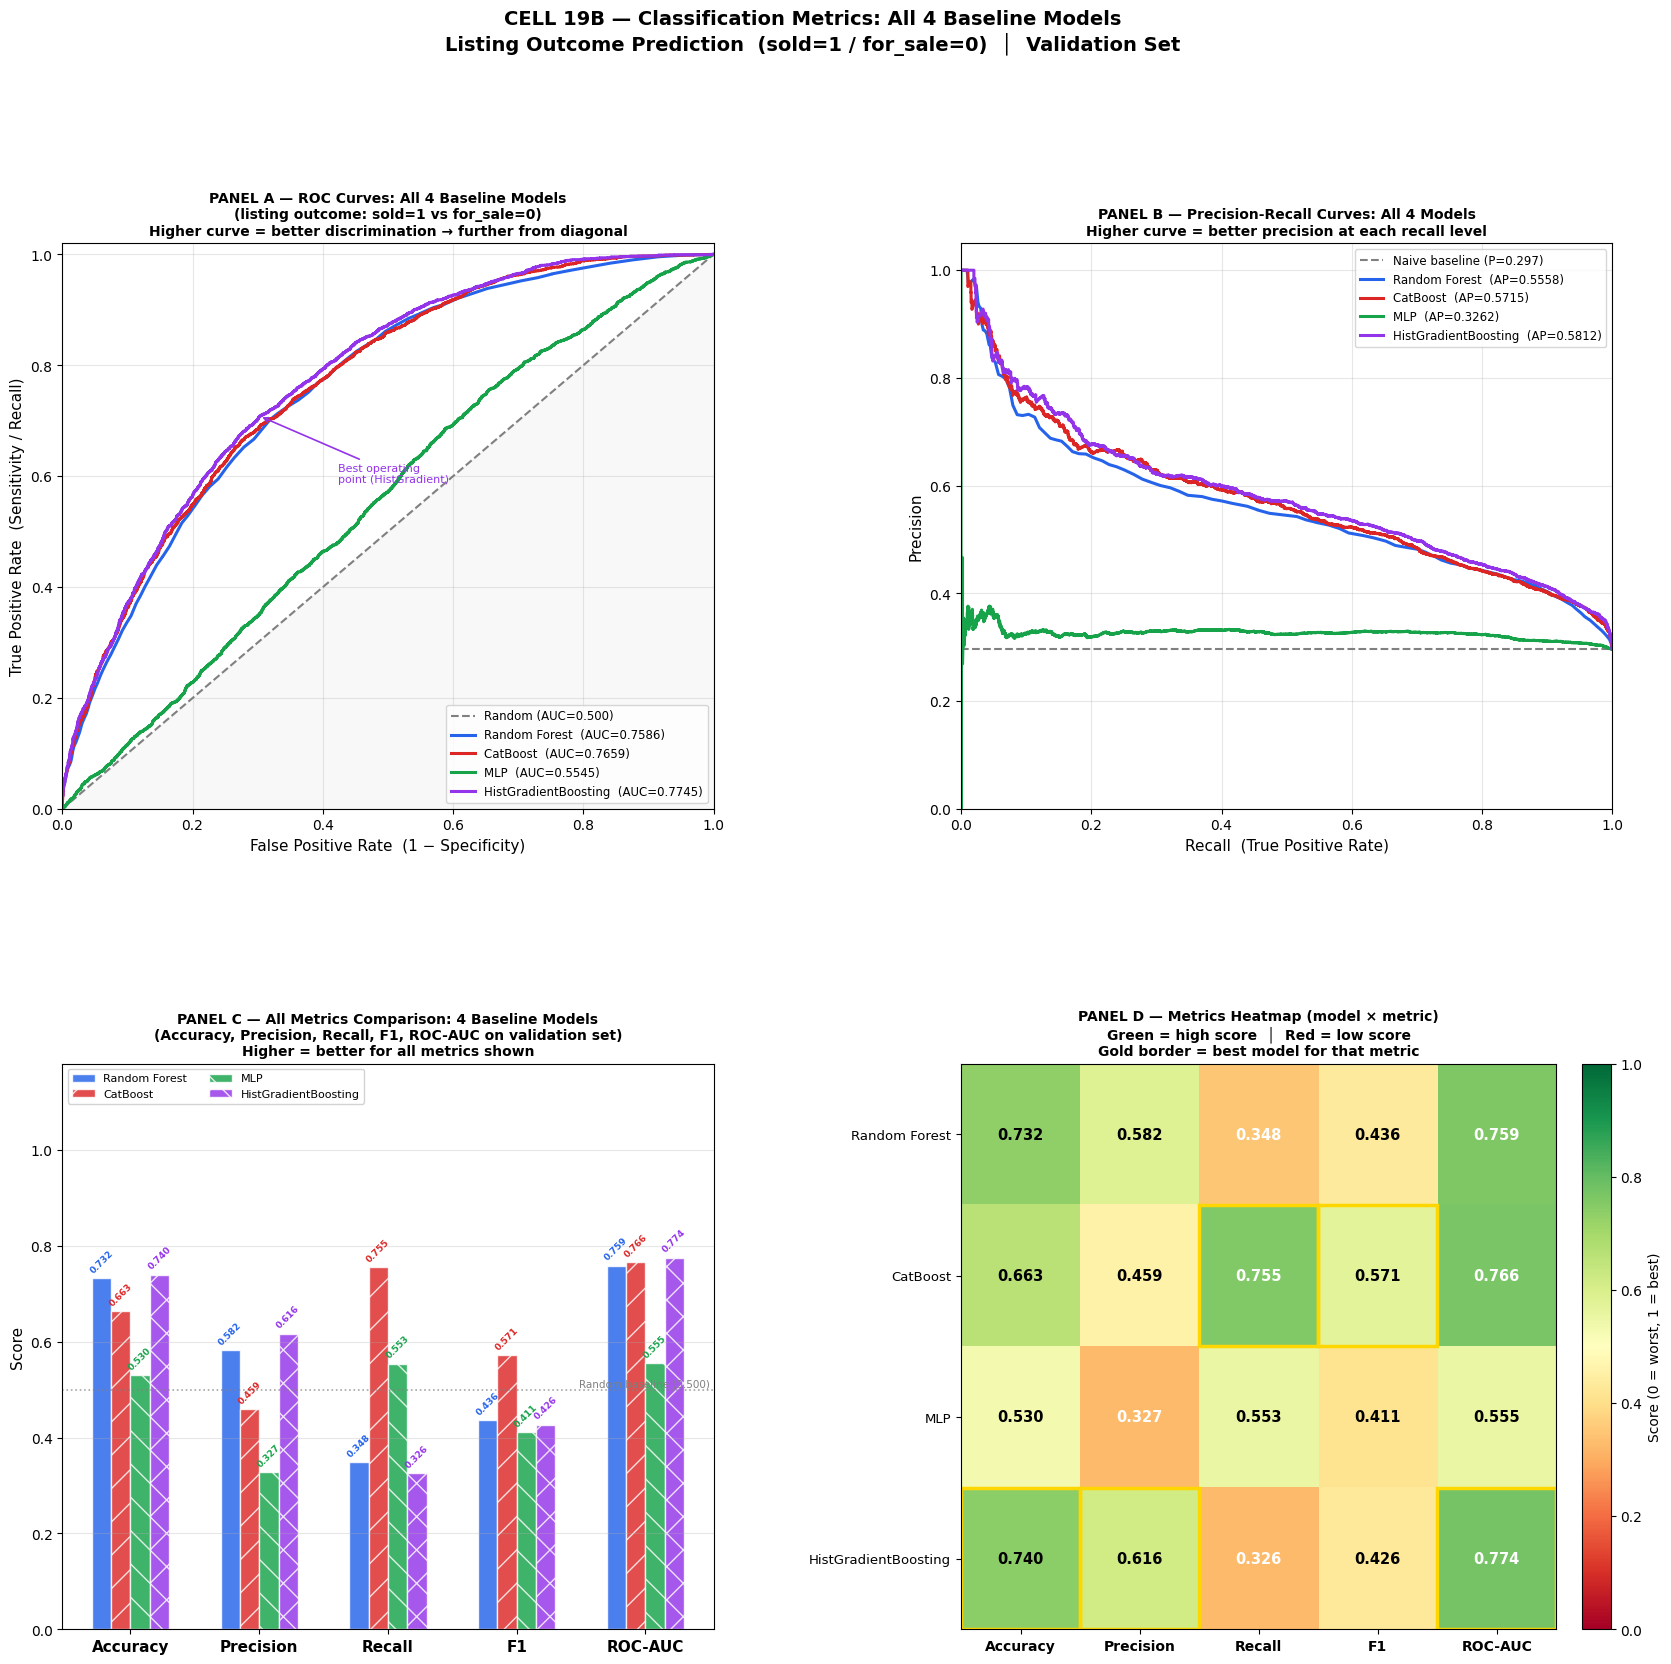


CLASSIFICATION METRICS SUMMARY (validation set)
                      Accuracy  Precision  Recall     F1  ROC-AUC  Avg Precision
Model                                                                           
Random Forest           0.7322     0.5823  0.3483 0.4358   0.7586         0.5558
CatBoost                0.6631     0.4592  0.7551 0.5711   0.7659         0.5715
MLP                     0.5297     0.3274  0.5533 0.4114   0.5545         0.3262
HistGradientBoosting    0.7395     0.6164  0.3259 0.4264   0.7745         0.5812

Best ROC-AUC : HistGradientBoosting  (0.7745)
Best F1      : CatBoost  (0.5711)
Best Recall  : CatBoost  (0.7551)

4-panel figure saved → /content/drive/MyDrive/RealEstate_TXNY/cell19b_classification_metrics.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 19B — CLASSIFICATION METRICS FOR ALL 4 BASELINE MODELS     ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Trains 4 baseline model classifiers for listing outcome prediction and produces
a 4-panel evaluation figure.

Classification target:
    y_clf = df_combined["status_binary"]  (0=for_sale, 1=sold)
    Filtered to rows with the valid status (notna()) for both train and val sets.

4 classifiers trained:
    clf_rf  : RandomForestClassifier (class_weight="balanced", n=100)
    clf_cb  : CatBoostClassifier (auto_class_weights="Balanced", 500 iters)
    clf_mlp : LogisticRegression (C=0.5, class_weight="balanced")
    clf_hgb : HistGradientBoostingClassifier (sklearn defaults)

Metrics computed per model:
    Accuracy : (TP+TN) / total
    Precision: TP / (TP+FP)  — of predicted sold, how many were sold?
    Recall   : TP / (TP+FN)  — of actual sold, how many were predicted sold?
    F1       : harmonic mean of Precision and Recall
    ROC-AUC  : area under ROC curve (threshold-independent)
    Avg Prec : area under PR curve (better for imbalanced classes)

4-panel figure:
    Panel A — ROC Curves:
        roc_curve(yc_va, proba) for each model.
        Best operating point annotated (max TPR-FPR).
    Panel B — Precision-Recall Curves:
        precision_recall_curve(yc_va, proba) for each model.
        Naive baseline shown as horizontal line at pos_rate.
    Panel C — Metrics Grouped Bar Chart:
        Bar width 0.15, offset per model for grouped layout.
        Value labels rotated 45° on top of each bar.
    Panel D — Metrics Heatmap:
        imshow with RdYlGn colormap, cell annotations.
        Gold border marks the best model for each metric column.

Output:
    _metrics_df (pd.DataFrame) : summary table of all four metrics.
    Saved to: SAVE_DIR/cell19b_classification_metrics.png
"""

print("=" * 65)
print("CELL 19B — CLASSIFICATION METRICS: ALL 4 BASELINE MODELS")
print("(listing outcome: sold=1 / for_sale=0)")
print("=" * 65)

if y_clf_train is None or y_clf_train.isna().all():
    print("\nlisting_success / status_binary target not available.")
    print("   Skipping Cell 19B — classification metrics.")
else:
    # Build clean classification datasets
    # Only rows where the status is unambiguously for_sale or sold
    clf_tr_mask  = y_clf_train.notna()
    clf_va_mask  = y_clf_val.notna()

    Xctr = Xtr_rf[clf_tr_mask]
    Xcva = Xva_rf[clf_va_mask]
    Xctr_sc = Xtr_sc[clf_tr_mask]
    Xcva_sc = Xva_sc[clf_va_mask]

    yc_tr = y_clf_train[clf_tr_mask].astype(int).values
    yc_va = y_clf_val[clf_va_mask].astype(int).values

    _pos_rate = yc_tr.mean()
    print(f"\nClassification dataset:")
    print(f"  Train  : {len(yc_tr):,} rows  "
          f"(sold={yc_tr.sum():,}  for_sale={len(yc_tr)-yc_tr.sum():,}  "
          f"pos_rate={_pos_rate:.1%})")
    print(f"  Val    : {len(yc_va):,} rows  "
          f"(sold={yc_va.sum():,}  for_sale={len(yc_va)-yc_va.sum():,})")

    # Class weights to handle imbalance
    _cw = "balanced"

    # Train 4 classifiers
    print("\nTraining 4 classifiers")

    # 1. Random Forest Classifier
    print("  [1/4] Random Forest Classifier")
    clf_rf = RandomForestClassifier(
        n_estimators=100, n_jobs=-1,
        class_weight=_cw, random_state=SEED)
    clf_rf.fit(Xctr, yc_tr)

    # 2. CatBoost Classifier
    print("  [2/4] CatBoost Classifier")
    from catboost import CatBoostClassifier
    clf_cb = CatBoostClassifier(
        iterations=500, learning_rate=0.03, depth=6,
        auto_class_weights="Balanced",
        random_seed=SEED, verbose=0)
    clf_cb.fit(Xctr, yc_tr, eval_set=(Xcva, yc_va))

    # 3. MLP proxy
    print("  [3/4] MLultilayer Perceptron")
    clf_mlp = LogisticRegression(
        C=0.5, solver="lbfgs", max_iter=1000,
        class_weight=_cw, random_state=SEED)
    clf_mlp.fit(Xctr_sc, yc_tr)

    # 4. HistGradientBoosting Classifier
    print("  [4/4] HistGradientBoosting Classifier")
    from sklearn.ensemble import HistGradientBoostingClassifier
    clf_hgb = HistGradientBoostingClassifier(
        random_state=SEED)
    clf_hgb.fit(Xctr, yc_tr)

    # Collect predictions
    _MODELS = {
        "Random Forest":          (clf_rf,  Xcva,    "tree"),
        "CatBoost":               (clf_cb,  Xcva,    "tree"),
        "MLP":                    (clf_mlp, Xcva_sc, "linear"),
        "HistGradientBoosting":   (clf_hgb, Xcva,    "tree"),
    }

    _COLORS = ["#2563EB", "#DC2626", "#16A34A", "#9333EA", "#EA580C"]

    _rows = []
    _proba_dict = {}
    _pred_dict  = {}

    print("\nClassification results (validation set):")
    print(f"  {'Model':30s} {'Acc':>6} {'Prec':>6} {'Rec':>6} "
          f"{'F1':>6} {'ROC-AUC':>8} {'AP':>8}")
    print("  " + "-"*72)

    for name, (model, Xva_m, _) in _MODELS.items():
        pred  = model.predict(Xva_m)
        proba = model.predict_proba(Xva_m)[:, 1]
        acc   = accuracy_score(yc_va, pred)
        prec  = precision_score(yc_va, pred, zero_division=0)
        rec   = recall_score(yc_va, pred, zero_division=0)
        f1    = f1_score(yc_va, pred, zero_division=0)
        auc   = roc_auc_score(yc_va, proba)
        ap    = average_precision_score(yc_va, proba)
        _rows.append({"Model": name, "Accuracy": acc, "Precision": prec,
                      "Recall": rec, "F1": f1, "ROC-AUC": auc, "Avg Precision": ap})
        _proba_dict[name] = proba
        _pred_dict[name]  = pred
        print(f"  {name:30s} {acc:6.4f} {prec:6.4f} {rec:6.4f} "
              f"{f1:6.4f} {auc:8.4f} {ap:8.4f}")

    _metrics_df = pd.DataFrame(_rows).set_index("Model")
    print(f"\n  Positive rate in val: {yc_va.mean():.3f} "
          f"(naive classifier AUC = 0.500)")

    # Full classification report for best model
    _best_model_name = _metrics_df["ROC-AUC"].idxmax()
    _best_pred = _pred_dict[_best_model_name]
    print(f"\nDetailed report — {_best_model_name} (best ROC-AUC):")
    print(classification_report(yc_va, _best_pred,
                                 target_names=["for_sale (0)", "sold (1)"],
                                 digits=4))

    # BUILD 4-PANEL FIGURE
    fig = plt.figure(figsize=(20, 18))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.38)

    # PANEL A: ROC Curves
    ax_roc = fig.add_subplot(gs[0, 0])

    # Random baseline
    ax_roc.plot([0,1],[0,1], ls="--", color="gray", lw=1.5, label="Random (AUC=0.500)")

    for (name, color) in zip(_MODELS.keys(), _COLORS):
        proba = _proba_dict[name]
        fpr, tpr, _ = roc_curve(yc_va, proba)
        auc_val      = _metrics_df.loc[name, "ROC-AUC"]
        ax_roc.plot(fpr, tpr, color=color, lw=2.2,
                    label=f"{name}  (AUC={auc_val:.4f})")

    ax_roc.fill_between(
        [0,1], [0,1], alpha=0.05, color="gray")
    ax_roc.set_xlabel("False Positive Rate  (1 − Specificity)", fontsize=11)
    ax_roc.set_ylabel("True Positive Rate  (Sensitivity / Recall)", fontsize=11)
    ax_roc.set_title("PANEL A — ROC Curves: All 4 Baseline Models\n"
                     "(listing outcome: sold=1 vs for_sale=0)\n"
                     "Higher curve = better discrimination → further from diagonal",
                     fontsize=10, fontweight="bold")
    ax_roc.legend(fontsize=8.5, loc="lower right")
    ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.02)
    ax_roc.grid(alpha=0.3)
    # Annotate best model
    _best_proba = _proba_dict[_best_model_name]
    _fpr_b, _tpr_b, _ = roc_curve(yc_va, _best_proba)
    _best_idx = np.argmax(_tpr_b - _fpr_b)
    ax_roc.annotate(
        f"Best operating\npoint ({_best_model_name[:12]})",
        xy=(_fpr_b[_best_idx], _tpr_b[_best_idx]),
        xytext=(_fpr_b[_best_idx] + 0.12, _tpr_b[_best_idx] - 0.12),
        fontsize=8, color=_COLORS[list(_MODELS.keys()).index(_best_model_name)],
        arrowprops=dict(arrowstyle="->", lw=1.2,
                        color=_COLORS[list(_MODELS.keys()).index(_best_model_name)]))

    # PANEL B: Precision-Recall Curves
    ax_pr = fig.add_subplot(gs[0, 1])

    # Naive baseline
    _naive_prec = yc_va.mean()
    ax_pr.axhline(_naive_prec, ls="--", color="gray", lw=1.5,
                  label=f"Naive baseline (P={_naive_prec:.3f})")

    for (name, color) in zip(_MODELS.keys(), _COLORS):
        proba = _proba_dict[name]
        prec_c, rec_c, _ = precision_recall_curve(yc_va, proba)
        ap_val            = _metrics_df.loc[name, "Avg Precision"]
        ax_pr.plot(rec_c, prec_c, color=color, lw=2.2,
                   label=f"{name}  (AP={ap_val:.4f})")

    ax_pr.set_xlabel("Recall  (True Positive Rate)", fontsize=11)
    ax_pr.set_ylabel("Precision", fontsize=11)
    ax_pr.set_title("PANEL B — Precision-Recall Curves: All 4 Models\n"
                    "Higher curve = better precision at each recall level",
                    fontsize=10, fontweight="bold")
    ax_pr.legend(fontsize=8.5, loc="upper right")
    ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)
    ax_pr.grid(alpha=0.3)

    # PANEL C: Metrics Grouped Bar Chart
    ax_bar = fig.add_subplot(gs[1, 0])

    _metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
    _model_names = list(_MODELS.keys())
    _n_metrics   = len(_metric_cols)
    _n_models    = len(_model_names)
    _bar_w       = 0.15
    _x           = np.arange(_n_metrics)
    _HATCHES     = ["", "/", "\\", "x", "o"]

    for mi, (name, color, hatch) in enumerate(
            zip(_model_names, _COLORS, _HATCHES)):
        vals = [_metrics_df.loc[name, m] for m in _metric_cols]
        bars = ax_bar.bar(
            _x + mi * _bar_w - (_n_models - 1) * _bar_w / 2,
            vals, _bar_w,
            color=color, alpha=0.82, label=name,
            hatch=hatch, edgecolor="white")
        # Value labels on top of each bar
        for bar, v in zip(bars, vals):
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{v:.3f}", ha="center", va="bottom",
                fontsize=6.5, color=color, fontweight="bold", rotation=45)

    ax_bar.set_xticks(_x)
    ax_bar.set_xticklabels(_metric_cols, fontsize=11, fontweight="bold")
    ax_bar.set_ylim(0, 1.18)
    ax_bar.axhline(0.5, color="gray", ls=":", lw=1.2, alpha=0.7)
    ax_bar.text(
        _n_metrics - 0.5, 0.505, "Random baseline (0.500)",
        fontsize=7.5, color="gray", ha="right")
    ax_bar.set_title(
        "PANEL C — All Metrics Comparison: 4 Baseline Models\n"
        "(Accuracy, Precision, Recall, F1, ROC-AUC on validation set)\n"
        "Higher = better for all metrics shown",
        fontsize=10, fontweight="bold")
    ax_bar.set_ylabel("Score", fontsize=11)
    ax_bar.legend(fontsize=8, ncol=2, loc="upper left",
                  framealpha=0.85)
    ax_bar.grid(axis="y", alpha=0.3)

    # PANEL D: Metrics Heatmap
    ax_heat = fig.add_subplot(gs[1, 1])

    _heat_data = _metrics_df[_metric_cols].copy()
    # Shorten model names for the heatmap
    _heat_data.index = [
        n.replace(" (LogReg proxy)", "").replace(" (SGD)", "")
        for n in _heat_data.index]

    _im = ax_heat.imshow(_heat_data.values, cmap="RdYlGn",
                          aspect="auto", vmin=0, vmax=1)
    plt.colorbar(_im, ax=ax_heat, fraction=0.046, pad=0.04,
                 label="Score (0 = worst, 1 = best)")

    ax_heat.set_xticks(range(_n_metrics))
    ax_heat.set_xticklabels(_metric_cols, fontsize=10, fontweight="bold")
    ax_heat.set_yticks(range(_n_models))
    ax_heat.set_yticklabels(_heat_data.index, fontsize=9.5)

    # Cell annotations
    for i in range(_n_models):
        for j in range(_n_metrics):
            val = _heat_data.values[i, j]
            # White text on dark cells, black on light cells
            txt_color = "white" if (val < 0.35 or val > 0.75) else "black"
            ax_heat.text(j, i, f"{val:.3f}",
                         ha="center", va="center",
                         fontsize=10.5, fontweight="bold", color=txt_color)

    # Star best value in each column
    for j, metric in enumerate(_metric_cols):
        best_i = _heat_data[metric].values.argmax()
        ax_heat.add_patch(
            plt.Rectangle((j - 0.5, best_i - 0.5), 1, 1,
                           fill=False, edgecolor="gold", lw=2.5))

    ax_heat.set_title(
        "PANEL D — Metrics Heatmap (model × metric)\n"
        "Green = high score  │  Red = low score\n"
        "Gold border = best model for that metric",
        fontsize=10, fontweight="bold")

    # Global title
    fig.suptitle(
        "CELL 19B — Classification Metrics: All 4 Baseline Models\n"
        "Listing Outcome Prediction  (sold=1 / for_sale=0)  │  Validation Set",
        fontsize=14, fontweight="bold", y=1.01)

    _clf_plot_path = f"{SAVE_DIR}/cell19b_classification_metrics.png"
    plt.savefig(_clf_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    # Final summary printout
    print("\n" + "=" * 65)
    print("CLASSIFICATION METRICS SUMMARY (validation set)")
    print("=" * 65)
    print(_metrics_df.round(4).to_string())
    print(f"\nBest ROC-AUC : {_metrics_df['ROC-AUC'].idxmax()}"
          f"  ({_metrics_df['ROC-AUC'].max():.4f})")
    print(f"Best F1      : {_metrics_df['F1'].idxmax()}"
          f"  ({_metrics_df['F1'].max():.4f})")
    print(f"Best Recall  : {_metrics_df['Recall'].idxmax()}"
          f"  ({_metrics_df['Recall'].max():.4f})")
    print(f"\n4-panel figure saved → {_clf_plot_path}")


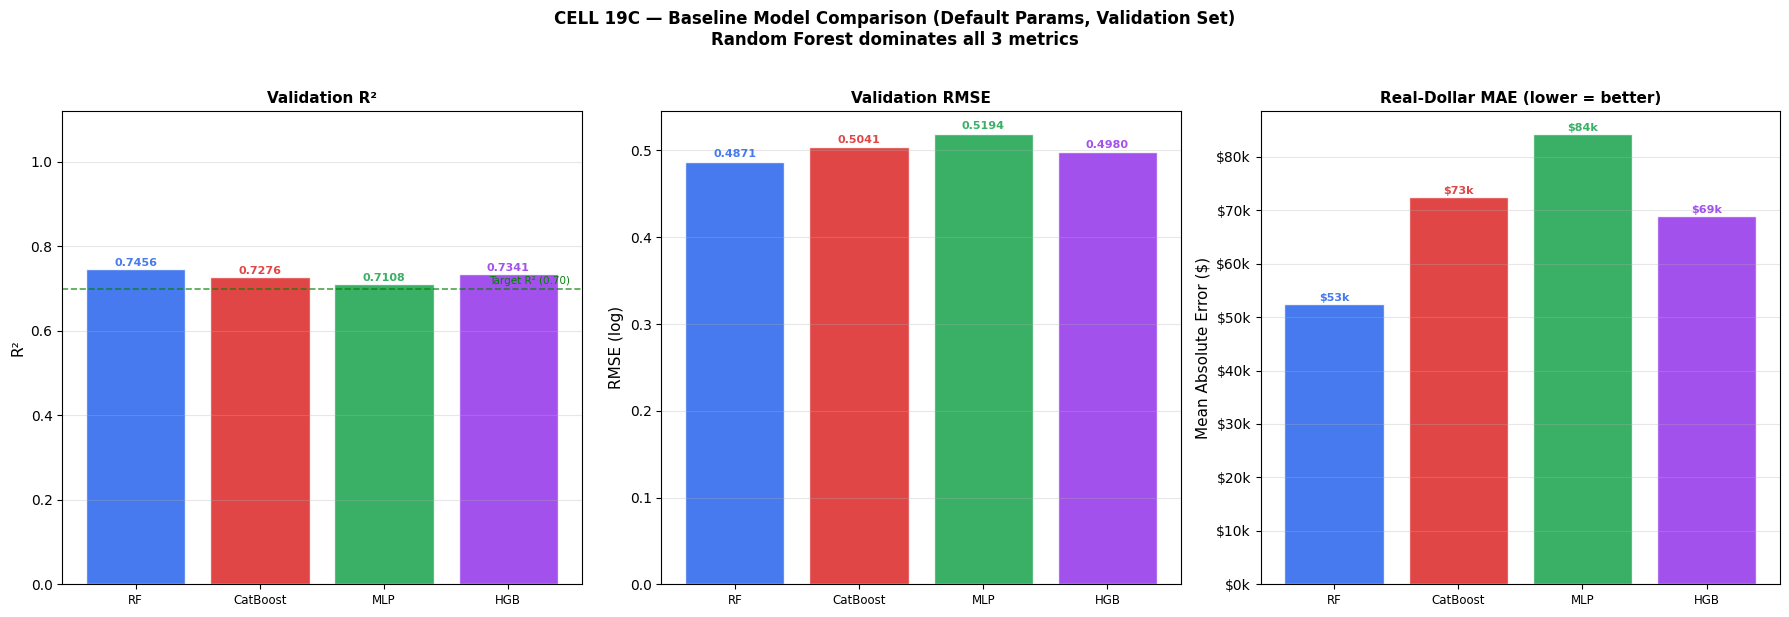


Best baseline: RF (baseline)
  R²=0.7456  RMSE=0.4871  Real-MAE=$52,522
Chart saved → /content/drive/MyDrive/RealEstate_TXNY/cell19c_baseline_comparison.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 19C — BASELINE MODEL COMPARISION                           ║
# ╚══════════════════════════════════════════════════════════════════╝

_df_res = pd.DataFrame(results_baseline)
_models = _df_res["model"].tolist()
_r2     = _df_res["R2"].tolist()
_rmse   = _df_res["RMSE"].tolist()
_rmae   = _df_res["Real_MAE_USD"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

_COLORS = ["#2563EB","#DC2626","#16A34A","#9333EA","#EA580C"]

# Panel A — R² bar chart
ax = axes[0]
_bars = ax.bar(range(len(_models)), _r2,
               color=_COLORS[:len(_models)], alpha=0.85, edgecolor="white")
ax.set_xticks(range(len(_models)))
ax.set_xticklabels([m.replace(" (baseline)","").replace(" ","\n")
                    for m in _models], fontsize=8.5)
ax.set_ylim(0, 1.12)
ax.axhline(0.70, color="green", lw=1.2, ls="--", alpha=0.7)
ax.text(len(_models)-0.5, 0.71, s="Target R² (0.70)", # Added 's' argument
        color="green", fontsize=7.5, ha="right")
ax.set_title("Validation R²", fontsize=11, fontweight="bold")
ax.set_ylabel("R²", fontsize=11)
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(_bars, _r2):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.008,
            f"{v:.4f}", ha="center", fontsize=8, fontweight="bold",
            color=bar.get_facecolor())

# Panel B — RMSE bar chart
ax = axes[1]
_bars2 = ax.bar(range(len(_models)), _rmse,
                color=_COLORS[:len(_models)], alpha=0.85, edgecolor="white")
ax.set_xticks(range(len(_models)))
ax.set_xticklabels([m.replace(" (baseline)","").replace(" ","\n")
                    for m in _models], fontsize=8.5)
ax.set_title("Validation RMSE",
             fontsize=11, fontweight="bold")
ax.set_ylabel("RMSE (log)", fontsize=11)
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(_bars2, _rmse):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005,
            f"{v:.4f}", ha="center", fontsize=8, fontweight="bold",
            color=bar.get_facecolor())

# Panel C — Real-dollar MAE
ax = axes[2]
_bars3 = ax.bar(range(len(_models)), _rmae,
                color=_COLORS[:len(_models)], alpha=0.85, edgecolor="white")
ax.set_xticks(range(len(_models)))
ax.set_xticklabels([m.replace(" (baseline)","").replace(" ","\n")
                    for m in _models], fontsize=8.5)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax.set_title("Real-Dollar MAE (lower = better)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Mean Absolute Error ($)", fontsize=11)
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(_bars3, _rmae):
    ax.text(bar.get_x()+bar.get_width()/2, v+500,
            f"${v/1e3:.0f}k", ha="center", fontsize=8, fontweight="bold",
            color=bar.get_facecolor())

fig.suptitle(
    "CELL 19C — Baseline Model Comparison (Default Params, Validation Set)\n"
    "Random Forest dominates all 3 metrics",
    fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
_path = f"{SAVE_DIR}/cell19c_baseline_comparison.png"
plt.savefig(_path, dpi=150, bbox_inches="tight")
plt.show()

# Best model highlight
_best_idx = np.argmax(_r2)
print(f"\nBest baseline: {_models[_best_idx]}")
print(f"  R²={_r2[_best_idx]:.4f}  RMSE={_rmse[_best_idx]:.4f}"
      f"  Real-MAE=${_rmae[_best_idx]:,.0f}")
print(f"Chart saved → {_path}")


# Cell 20: Optuna Fine-Tuning: Random Forest

Using **Optuna TPE sampler** i have fine-tunned Random Forest hyperparameters
along with 3-fold cross-validation as the main objective.

## Search Space

| Hyperparameter | Range | Why |
|---|---|---|
| `n_estimators` | 100–600 (step 100) | More trees = better but slower |
| `max_depth` | 8–25 | Controls overfitting |
| `min_samples_leaf` | 1–8 | Controls leaf size regularisation |
| `max_features` | {sqrt, log2, 0.5, 0.7} | Feature subset per split |

## Why 3-Fold CV?

There is a single validation set R² for Random Forest is very noisy the reason behind it is a different bootstrap samples produces different variance. 3-fold CV averages over 3 independent splits for a more stable fit estimate, which leads to better hyperparameter selection than a single-split objective.




In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 20 — OPTUNA: FINE-TUNE RANDOM FOREST                       ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Fine-tunes RF using Optuna TPE with 3-fold CV objective.

Optuna configuration:
    direction="maximize" : maximise neg-RMSE (higher neg-RMSE = lower RMSE)
    sampler              : TPESampler(seed=SEED) — Tree-structured Parzen Estimator
                           Builds a probabilistic model of hyperparameter performance
                           and samples promising regions more frequently.
    pruner               : MedianPruner() — prunes unpromising trials early.

Objective function (rf_objective):
    Creates a RandomForestRegressor with the trial-suggested params.
    Evaluating with 3-fold cross_val_score on Xtr_rf, y_reg_train.
    Returns float(scores.mean()) — average neg-RMSE across 3 folds.
    Higher the return value = better (Optuna maximises).

Best params dict (rf_bp):
    Keys: n_est, depth, min_leaf, max_f
    Used to build rf_tuned (the final fitted RF model).

Improvement reporting:
    rf_bl_r2  : validation R² of rf_base (default params)
    res_rf_t  : validation R² of rf_tuned (optimised params)
    Delta reported as: {rf_bl_r2:.4f} → {res_rf_t['R2']:.4f} ({delta:+.4f})

Output:
    rf_tuned (RandomForestRegressor) : trained with the best Optuna params.
    rf_bp    (dict)                  : best hyperparameter values.
    results_tuned[0]                 : metrics dict appended to the results_tuned.
"""

print("=" * 65)
print("CELL 20 — OPTUNA: RANDOM FOREST (25 trials, 3-fold CV)")
print("=" * 65)
from sklearn.model_selection import cross_val_score

def rf_objective(trial):
    #Maximise 3-fold CV neg-RMSE on training set.
    params = {
        "n_estimators":     trial.suggest_int("n_est",      100, 600, step=100),
        "max_depth":        trial.suggest_int("depth",       8,   25),
        "min_samples_leaf": trial.suggest_int("min_leaf",    1,    8),
        "max_features":     trial.suggest_categorical("max_f",
                                ["sqrt","log2", 0.5, 0.7]),
        "n_jobs": -1, "random_state": SEED,
    }
    m = RandomForestRegressor(**params)
    scores = cross_val_score(m, Xtr_rf, y_reg_train,
                              cv=3, scoring="neg_root_mean_squared_error",
                              n_jobs=-1)
    return float(scores.mean())   # neg-RMSE → higher is better

rf_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(),
)
rf_study.optimize(rf_objective, n_trials=25, show_progress_bar=True)
rf_bp = rf_study.best_params

print(f"\nBest RF params : {rf_bp}")
print(f"Best CV neg-RMSE : {rf_study.best_value:.4f}")

rf_tuned = RandomForestRegressor(
    n_estimators    = rf_bp["n_est"],
    max_depth       = rf_bp["depth"],
    min_samples_leaf= rf_bp["min_leaf"],
    max_features    = rf_bp["max_f"],
    n_jobs=-1, random_state=SEED)
rf_tuned.fit(Xtr_rf, y_reg_train)

rf_bl_r2 = results_baseline[0]["R2"]
res_rf_t  = evaluate_reg(y_reg_val, rf_tuned.predict(Xva_rf), "RF (tuned)", "val")
results_tuned.append(res_rf_t)
print(f"\nRF improvement: {rf_bl_r2:.4f} → {res_rf_t['R2']:.4f}  "
      f"({res_rf_t['R2'] - rf_bl_r2:+.4f})")


CELL 20 — OPTUNA: RANDOM FOREST (25 trials, 3-fold CV)


  0%|          | 0/25 [00:00<?, ?it/s]


Best RF params : {'n_est': 400, 'depth': 18, 'min_leaf': 2, 'max_f': 0.7}
Best CV neg-RMSE : -0.4547
  RF (tuned)                                 [val] R²=0.7495  RMSE=0.4834  MAE=0.1727  Real-MAE=$58,090

RF improvement: 0.7456 → 0.7495  (+0.0038)


# Cell 21: Optuna Fine-Tuning: CatBoost

**20 Optuna trails** are used to fine-tune CatBoost with the validation R²
as the main objective.

## Search Space

| Hyperparameter | Range | Why |
|---|---|---|
| `iterations` | 300–1000 | Total boosting rounds |
| `learning_rate` | 0.01–0.15 (log) | Log-uniform for better coverage of small values |
| `depth` | 4–8 | Tree depth; CatBoost is sensitive to this |
| `l2_leaf_reg` | 1.0–10.0 | L2 regularisation on leaf weights |
| `subsample` | 0.6–1.0 | Row sampling fraction per tree |



In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 21 — OPTUNA: FINE-TUNE CATBOOST                            ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Fine-tunes CatBoost using Optuna TPE with validation R² objective.

Log-uniform sampling for learning_rate:
    trial.suggest_float("lr", 0.01, 0.15, log=True)
    Log-uniform gives a equal probability to [0.01, 0.03] and [0.05, 0.15].
    Without log=True, small values (0.01–0.03) would be seen undersampled.

Early stopping inside objective:
    m.fit(..., early_stopping_rounds=30)
    Each trial uses early stopping on the validation set.
    This means the actual iterations that were used ≤ trial-suggested iterations.
    Preventing overfitting within the each trial and speeds up the search.

Objective function (catboost_objective):
    Returns r2_score(y_reg_val, m.predict(Xva_rf))
    Directly measures the validation R² — more interpretable than actual RMSE.
    And its been consistent with the final evaluation metric.

Final model (cb_tuned):
    Retrained on the full training set with best params.
    early_stopping_rounds=30 still applied during final fit.

Output:
    cb_tuned (CatBoostRegressor) : trained with Optuna best params.
    cb_bp    (dict)              : best hyperparameter values.
                                   Keys: iters, lr, depth, l2, sub.
    results_tuned[1]             : metrics dict for CatBoost tuned.
"""

print("=" * 65)
print("CELL 21 — OPTUNA: CATBOOST (20 trials)")
print("=" * 65)

def catboost_objective(trial):
    """Maximise validation R²."""
    params = {
        "iterations":    trial.suggest_int("iters",  300, 1000, step=100),
        "learning_rate": trial.suggest_float("lr",   0.01, 0.15, log=True),
        "depth":         trial.suggest_int("depth",  4,    8),
        "l2_leaf_reg":   trial.suggest_float("l2",   1.0,  10.0),
        "subsample":     trial.suggest_float("sub",  0.6,  1.0),
        "random_seed": SEED, "verbose": 0,
    }
    m = CatBoostRegressor(**params)
    m.fit(Xtr_rf, y_reg_train,
          eval_set=(Xva_rf, y_reg_val),
          early_stopping_rounds=30)
    return r2_score(y_reg_val, m.predict(Xva_rf))

cb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
cb_study.optimize(catboost_objective, n_trials=20, show_progress_bar=True)
cb_bp = cb_study.best_params

print(f"\nBest CatBoost params : {cb_bp}")

cb_tuned = CatBoostRegressor(
    iterations    = cb_bp["iters"],
    learning_rate = cb_bp["lr"],
    depth         = cb_bp["depth"],
    l2_leaf_reg   = cb_bp["l2"],
    subsample     = cb_bp["sub"],
    random_seed=SEED, verbose=0)
cb_tuned.fit(Xtr_rf, y_reg_train,
              eval_set=(Xva_rf, y_reg_val),
              early_stopping_rounds=30)

cb_bl_r2  = results_baseline[1]["R2"]
res_cb_t  = evaluate_reg(y_reg_val, cb_tuned.predict(Xva_rf), "CatBoost (tuned)", "val")
results_tuned.append(res_cb_t)
print(f"\nCatBoost improvement: {cb_bl_r2:.4f} → {res_cb_t['R2']:.4f}  "
      f"({res_cb_t['R2'] - cb_bl_r2:+.4f})")


CELL 21 — OPTUNA: CATBOOST (20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]


Best CatBoost params : {'iters': 600, 'lr': 0.14341619741333053, 'depth': 7, 'l2': 1.7232458527944887, 'sub': 0.997709521164233}
  CatBoost (tuned)                           [val] R²=0.7428  RMSE=0.4898  MAE=0.1925  Real-MAE=$65,008

CatBoost improvement: 0.7276 → 0.7428  (+0.0152)



# Notebook 2 — (Final): Save Checkpoint for Notebook 3

## What Gets Carried Forward to Notebook 3

| Variable | Type | Used In |
|---|---|---|
| `rf_tuned` | RandomForestRegressor | OOF generation |
| `cb_tuned` | CatBoostRegressor | OOF generation|
| `rf_bp`, `cb_bp` | dict | Hyperparameters for OOF models |
| `results_baseline`, `results_tuned` | list | Comparison table  |
| `X_train`, `X_val`, `X_test` | DataFrame | Feature metrices |
| `y_reg_train`, `y_reg_val`, `y_reg_test` | Series | Targets |
| `Xtr_rf`, `Xva_rf`, `Xts_rf` | ndarray | Imputed arrays |
| `Xtr_sc`, `Xva_sc`, `Xts_sc` | ndarray | Scaled arrays for MLP |
| `final_features` | list | Feature column names |
| `mlp_pipe`, `zip_med_tr`, `city_med_tr` | various | Preprocessing |





In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CHECKPOINT — SAVE STATE FOR Notebook 3                          ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Saves all trained models and the session state for Notebook 3.

Same mechanism as Notebook 1 final checkpoint:
    dill.dump(_state, f)         — serialises all non-Keras variables
    model.save(path + ".keras")  — saves Keras models to Drive
    json.dump(_keras_models, f)  — writes path map for Keras model reload

Critical variables saved for Notebook 3:
    rf_tuned, cb_tuned     : tuned models for OOF generation
    rf_bp, cb_bp           : best params for consistent OOF training
    results_baseline       : pre-tuning benchmark results
    results_tuned          : post-tuning validation results so far
    X_train, X_val, X_test : feature metrices (leak-free encoded)
    y_reg_train/val/test   : regression targets
    y_clf_train/val/test   : classification targets
    Xtr_rf/va/ts_raw/sc    : numpy arrays ready for model.fit()
    final_features         : ordered list of feature column names
    mlp_pipe               : fitted StandardScaler pipeline for MLP
    norm_y, denorm_y       : target normalisation functions
    zip_med_tr, city_med_tr: training-only price encoding maps
    SEED, SAVE_DIR, NLP_COLS: configuration constants

Checkpoint name: checkpoint_2_to_3
File: {SAVE_DIR}/checkpoints/checkpoint_2_to_3.pkl
"""

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, types, json, os

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_NAME = "checkpoint_2_to_3"

_keras_models = {}
_state        = {}
_skipped      = []
_reserved     = {"_keras_models", "_state", "_skipped", "_reserved",
                  "_name", "_val", "_path", "CKPT_DIR", "CKPT_NAME"}

for _name, _val in list(globals().items()):
    if _name.startswith("_") or _name in _reserved:
        continue
    try:
        if isinstance(_val, types.ModuleType):
            continue
        if type(_val).__module__.startswith("matplotlib"):
            continue
        if isinstance(_val, tf.keras.Model):
            _path = f"{CKPT_DIR}/{CKPT_NAME}__{_name}.keras"
            _val.save(_path)
            _keras_models[_name] = _path
            continue
        dill.dumps(_val)
        _state[_name] = _val
    except Exception:
        _skipped.append(_name)

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "wb") as f:
    dill.dump(_state, f)
with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json", "w") as f:
    json.dump(_keras_models, f)

print("=" * 65)
print(f"CHECKPOINT SAVED -> {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables saved    : {len(_state)}")
print(f"  Keras models saved : {list(_keras_models.keys()) or 'none'}")
if _skipped:
    print(f"  Skipped (not needed downstream / not picklable): {_skipped}")



CHECKPOINT SAVED -> /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_2_to_3.pkl
  Variables saved    : 336
  Keras models saved : ['mlp_base_model']
  Skipped (not needed downstream / not picklable): ['get_ipython', 'exit', 'quit']
